# Simulations Homework

In [1]:
import numpy as np
import seaborn as sns
%matplotlib inline

---

### Reset Generator Function

If you didn't do so in class, write a function to reseed the numpy random number generator. It should default to setting the seed to 42, but be able to set it to whatever you want.

In [2]:
def reset_rng(seed=42):
    return np.random.default_rng(seed)

Reset the generator using your function.

In [3]:
rng = reset_rng()

---

### "Accept Cookies" Simulation

Assuming the base rate for hitting the "Accept Cookies" button when landing on a website is 85%, do a set of 10,000 simulations of 20 people visiting a given website and accepting cookies. 

In [4]:
base_rate = 0.85
n_people = 20
n_simulations = 10_000

# Run simulations using binomial distribution
results = np.random.binomial(n_people, base_rate, size=n_simulations)

Based on your simulation, what is the probability of getting exactly 15 accepts? 

In [6]:
prob_exact_15 = np.mean(results == 15)
prob_exact_15

0.1024

What is the probability of getting *at least* 15 accepts?

In [7]:
prob_at_least_15 = np.mean(results >= 15)
prob_at_least_15

0.9316

What is the probability of getting fewer than 15 accepts?

In [8]:
prob_fewer_than_15 = np.mean(results < 15)
prob_fewer_than_15

0.0684

Confirm that the last two probabilities computed sum to 1.0.

In [9]:
prob_fewer_than_15 + prob_at_least_15

1.0

---

### What Is and Isn't Binomial?

Check the binomial approximation for the election simulations from the in-class notebook for the cases in which we did and didn't account for the poll-to-poll variability arising from a single poll.

What is the expected standard deviation for our distribution of election outcomes based on the normal approximation?

In [10]:
p_A = 0.51                 # probability of candidate A winning a single vote
n_voters = 100_000         # expected voter turnout
n_simulations = 20_000     # number of simulated elections

# Simulate the election
votes_A = rng.binomial(n=n_voters, p=p_A, size=n_simulations)

In [12]:
std_expected = np.sqrt(n_voters * p_A * (1 - p_A))
std_expected

158.082257068907

What was the empirical standard deviation of the distribution of election outcomes when we only used a single probability? ("*single poll, many elections*")

(You can just copy and paste the code from the in-class notebook to regenerate the simulated election outcomes.)

In [13]:
np.std(votes_A, ddof=1)

158.93809447534525

What was the empirical standard deviation of the distribution of election outcomes when we accounted for random variation in poll outcomes in our simulation? ("*simulate poll -> simulate election*")

In [14]:
p_true = 0.51
n_voters = 100_000
n_poll = 1_000          # poll sample size
n_simulations = 20_000

rng = np.random.default_rng()
#poll
poll_counts = rng.binomial(n=n_poll, p=p_true, size=n_simulations)
p_hat = poll_counts / n_poll
#election
votes_A = rng.binomial(n=n_voters, p=p_hat)

std_empirical = np.std(votes_A, ddof=1)
std_empirical

1598.4889768474766

---

### Effect of Poll Sample Size

As you have probably realized, these distributions of outcomes from many experiments we've been generating are, by definition, ***sampling distributions***! One firm law about sampling distributions is that their width depends strongly on sample size. As such, we would expect our simulated election outcomes to be affected by the size of the poll on which they are based.

In the cel"l below, run the *simulate poll -> simulate elections* code for poll sample sizes of 50, 100, 500, 1000, 2000 and 5000. For each sample size, record the obtained standard deviation of the distribution of outcomes. (pro tip: make a new code cell below and put them in a Python list)

In [25]:
 # reset generator
rng = reset_rng()

In [26]:
 # simulate
p_true = 0.51
n_voters = 100_000
n_simulations = 20_000
poll_sizes = [50, 100, 500, 1000, 2000, 5000]

rng = np.random.default_rng()

# Store all simulated elections
all_votes = {}

for n_poll in poll_sizes:
    poll_counts = rng.binomial(n=n_poll, p=p_true, size=n_simulations)
    p_hat = poll_counts / n_poll
    votes_A = rng.binomial(n=n_voters, p=p_hat)
    all_votes[n_poll] = votes_A

In [28]:
std_results = []

for n_poll in poll_sizes:
    sd = np.std(all_votes[n_poll], ddof=1)
    std_results.append(sd)

std_results

[7057.9441153399985,
 5003.522264304607,
 2254.9983586033286,
 1595.026326703915,
 1128.6863263278065,
 725.2472394025868]

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, 'Standard Deviation')

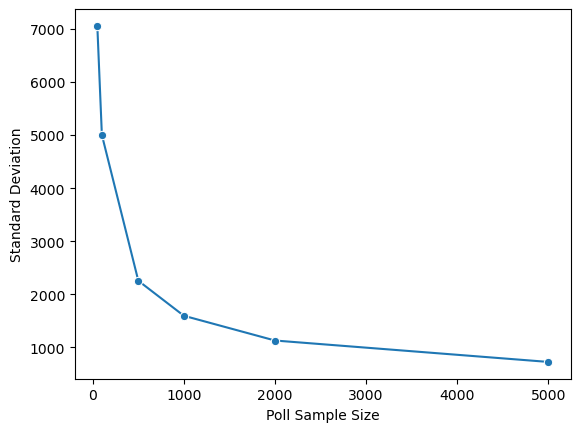

In [29]:
import matplotlib.pyplot as plt

 # plot
sns.lineplot(x=poll_sizes, y=std_results, marker="o")
plt.xlabel("Poll Sample Size")
plt.ylabel("Standard Deviation")

Make a plot of standard deviation of outcomes (y-axis) vs. poll sample size (x-axis).

Done above

Based on this plot, why do you think almost all polls sample around 2000 people?

Thats really when the poll starts to get diminishing returns

---

### Re-Write the Multi-Poll Code 

The code for combining three polls using a weighted average works, but it is awkward. Changing it to handle a different number of polls would involve lots of copying and pasting and mistake-prone editing.

Make the code "Pythonic" so that all you have to do is provide a list (or tuple) of poll results and another for poll weights, and your code will do the rest. 

Your code can be just code in a code cell. But if you're feeling spicy, you could make it a function!

In [30]:
def weighted_poll_average(poll_results, poll_weights):
    poll_results = np.array(poll_results)
    poll_weights = np.array(poll_weights)
    
    if len(poll_results) != len(poll_weights):
        raise ValueError("Poll results and weights must have the same length.")
    
    return np.average(poll_results, weights=poll_weights)

In [31]:
polls = [0.48, 0.51, 0.53]
weights = [800, 1200, 600]

combined_estimate = weighted_poll_average(polls, weights)
combined_estimate

0.5053846153846154

---

### Weight polls by sample size

Use your new code to compute predicted election outcomes based on 5 polls weighted by the sample sizes of the polls (or their square root, if you prefer – wink wink, nudge nudge). The polls are as follows:

`poll_ests = [.51, .55, .53, .49, 0.50]`

`poll_samp_szs = [2000, 1000, 1500, 1200, 1142]`

In [32]:
poll_ests = [.51, .55, .53, .49, 0.50]
poll_samp_szs = [2000, 1000, 1500, 1200, 1142]

predicted_p = weighted_poll_average(poll_ests, poll_samp_szs)
predicted_p

0.5150540777550424

Make a plot of the distribution of simulated outcomes, with the area representing the underdog winning highlighted.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, 'Density')

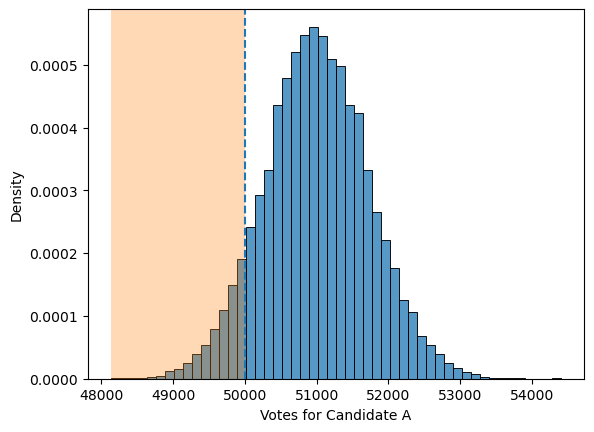

In [33]:
poll_counts = rng.binomial(n=n_poll, p=p_true, size=n_simulations)
p_hat = poll_counts / n_poll
votes_A = rng.binomial(n=n_voters, p=p_hat)

# Threshold for underdog win (A loses)
threshold = n_voters / 2
sns.histplot(votes_A, bins=50, stat="density")

# Highlight underdog-winning region
x_vals = np.linspace(min(votes_A), threshold, 500)
plt.axvline(threshold, linestyle="--")
plt.fill_between(x_vals, 0, 1, where=(x_vals <= threshold), alpha=0.3, transform=plt.gca().get_xaxis_transform())

plt.xlabel("Votes for Candidate A")
plt.ylabel("Density")

---

Bonus (totally optional): 
Write your own function, `my_binom()` that does the same thing as `rng.binomial()`. The function should use `rng.random()` internally. To the user, it should behave just like `rng.binomial()`!

---